# Objective:
 Clean the our data and prefor EDA

# Load and view dataset

In [ ]:

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.preprocessing import LabelEncoder


In [33]:
# load the dataset
data = pd.read_csv('../Data/spam.csv',encoding='latin-1')
# view first 5 records
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [34]:
# basic information about data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [35]:
data.shape

(5572, 5)

In [36]:
data.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

Obsarvation:

Netx Action:


# Data Cleaning

In [37]:
# drop col 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4' for containg many null values
data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace= True)
# check
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
# rename the column for better undersatnding
data.rename(columns={'v1':'target','v2':'messages'},inplace= True)
# check 
data.columns

Index(['target', 'messages'], dtype='str')

In [39]:
# check duplicate values
data.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
5567    False
5568    False
5569    False
5570    False
5571    False
Length: 5572, dtype: bool>

In [40]:
# drop duplicated values except one 
data = data.drop_duplicates(keep='first')
# check 
data.duplicated().sum()


np.int64(0)

> Now the data is much clean to Preform  EDA for better understanding 

# EDA

C:\Users\Avik Maity\AppData\Local\Temp\ipykernel_7292\1960646922.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=data,palette='Set2')


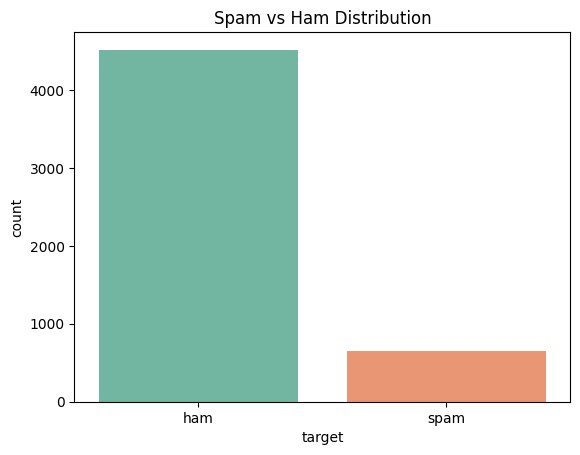

In [41]:
# value count of target data
sns.countplot(x='target', data=data,palette='Set2')
plt.title("Spam vs Ham Distribution")
plt.show();

> its a imbalance data

In [52]:
le = LabelEncoder()
# fit transform
data['target']=le.fit_transform(data['target'])

# check
data['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [42]:
# create  character word and sentance columns for better understanding of the dsta
# freature with number of characters 
data['num_characters'] = data['messages'].apply(len)
# feature with numver of words
data['num_words'] = data['messages'].apply(lambda x:len(nltk.word_tokenize(x)))
# featrues with numbers of sentances
data['num_sents'] = data['messages'].apply(lambda x:len(nltk.sent_tokenize(x)))

# check 
data.head()

,target,messages,num_characters,num_words,num_sents
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [43]:
# check its statical summary
data.describe()

,num_characters,num_words,num_sents
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [44]:
data.columns

Index(['target', 'messages', 'num_characters', 'num_words', 'num_sents'], dtype='str')

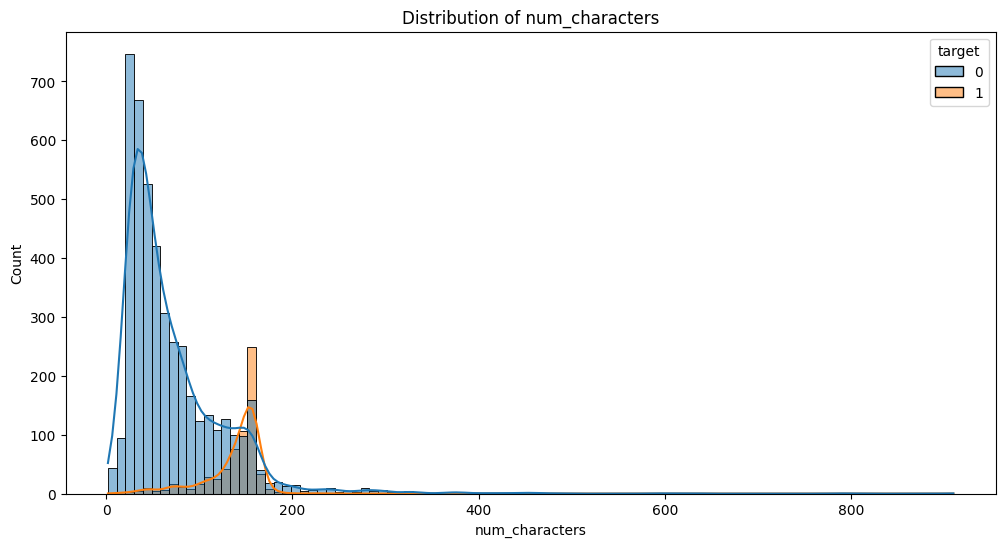

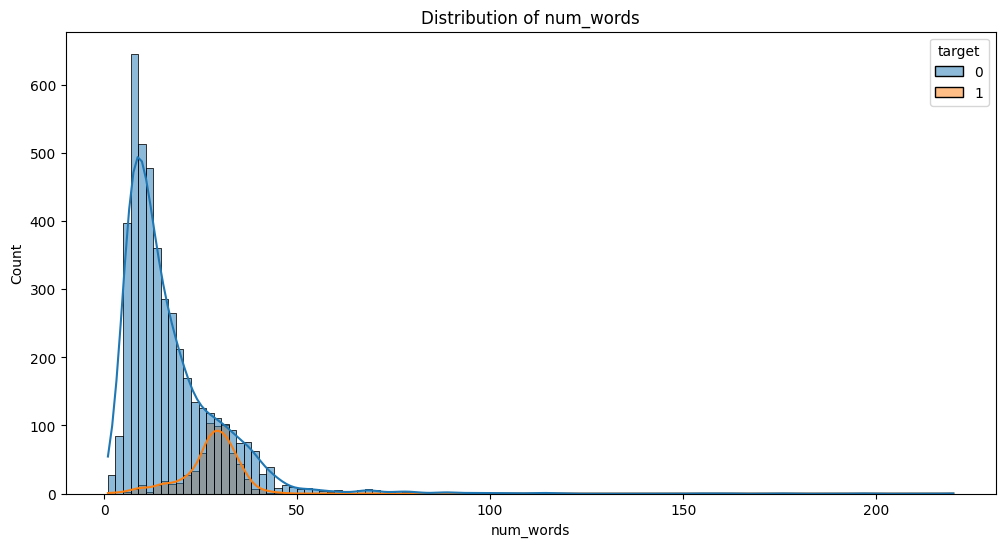

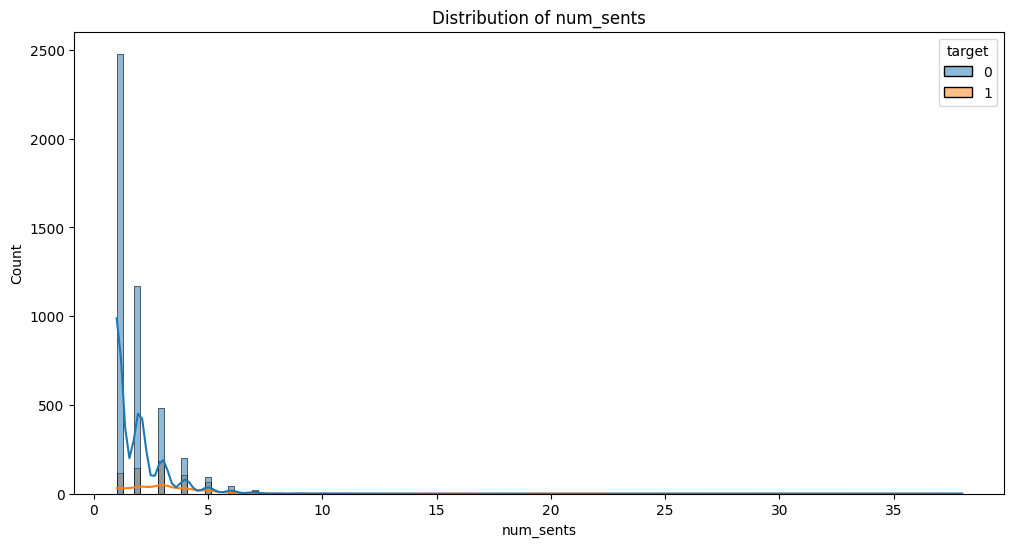

In [53]:
columns = ['num_characters', 'num_words', 'num_sents']

for col in columns:
    plt.figure(figsize=(12,6))
    
    sns.histplot(data=data, x=col, hue='target', kde=True)
    
    plt.title(f'Distribution of {col}')
    plt.show()

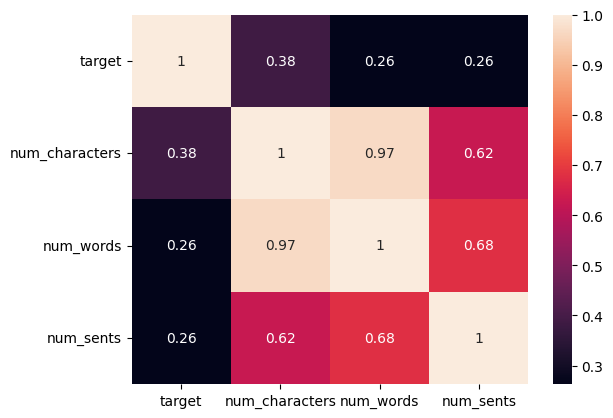

In [54]:
sns.heatmap(data.corr(numeric_only=True),annot=True);

> 1. There may multi colinarity exsist in num_word and num_sents
> 2. we can take num_characters  as infut feature

In [ ]:
# copy data 
df = data.copy()

In [58]:
# Take the importent columns
data = data[['target', 'messages', 'num_characters']]

In [59]:
# check 
data.info()

<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   target          5169 non-null   int64
 1   messages        5169 non-null   str  
 2   num_characters  5169 non-null   int64
dtypes: int64(2), str(1)
memory usage: 161.5 KB


## Save the data

In [60]:
data.to_csv('../Data/cleaned_data.csv', index=False)